# 1.3 Inverses, Rank, and A = CR

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter I — Matrices, Elimination, and Subspaces",
    number="1.3",
    title="Inverses, Rank, and A = CR",
    blurb="Why forming the inverse is almost always wrong, why row rank equals "
    "column rank for a one-line reason, and why 'the rank' of a floating-point "
    "matrix is a decision rather than a number.",
    difficulty="intermediate",
    estimate="75–105 min",
)

<ECP header: 2547 chars of HTML>

## Notebook overview

Two ideas here, and they pull in opposite directions.

The first is that $A^{-1}$, the object every hand calculation reaches for, is
something a numerical library goes out of its way to avoid. It exists, it is
computable, and computing it costs about three times a solve and returns an
answer that is *catastrophically less trustworthy*. We measure that: on a
system with $\kappa = 10^{10}$, `solve(A, b)` and `inv(A) @ b` differ by only a
factor of twelve in the accuracy of the answer, but by a factor of $10^{8}$ in
**backward error** — the quantity [§0.2](../00-machine/floating-point.ipynb)
introduced as the honest measure of whether an algorithm did its job. The
solve produces the exact answer to a problem a rounding error away from yours.
The inverse produces an answer to no nearby problem at all.

The second idea is **rank**, and it is where this course's exact-versus-float
spine bites hardest. In exact arithmetic rank is a theorem: the number of
independent columns, computed by elimination over the rationals, with no
ambiguity whatsoever. In floating point it is a *threshold* on singular values,
and different defensible thresholds give different answers for the same matrix.
The Prologue planted that question and [§0.2](../00-machine/floating-point.ipynb)
supplied the machinery; here we confront it directly, with SymPy's exact answer
printed beside NumPy's, and see precisely where they part company.

In between sits the factorization that makes rank concrete. $A = CR$ takes the
independent columns as $C$ and the recipe for rebuilding the rest as $R$, and
it proves in one line something that is otherwise a real theorem: **row rank
equals column rank**, for every matrix, always.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** The $A = CR$ framing and its proof of the rank theorem are
> Strang's {cite}`strang2023`, Chapter 3. For why the inverse is avoided, and
> the backward-error argument in full, Higham {cite}`higham2002` Chapter 14,
> whose title — "Matrix Inversion" — opens with the observation that the
> operation is far less often needed than supposed.

## Theory in brief

### The inverse, and why it is a detour

For square $A$ the inverse satisfies $AA^{-1} = A^{-1}A = I$, and its columns
are the solutions of $n$ linear systems:

```{math}
:label: eq-rank-inverse-columns
A\,\mathbf{x}_j = \mathbf{e}_j, \qquad A^{-1} = [\,\mathbf{x}_1\ \cdots\ \mathbf{x}_n\,].
```

So computing $A^{-1}$ *is* solving $n$ systems — one factorization plus $n$
pairs of triangular sweeps by [§1.2](elimination-lu.ipynb), which is
$\tfrac23 n^3 + 2n^3 = \tfrac83 n^3$ operations, about four times the cost of
the single solve you probably wanted.

Cost is the smaller objection. The real one is stability. Solving directly
gives a computed $\hat{\mathbf{x}}$ that is the *exact* solution of
$(A + \delta A)\hat{\mathbf{x}} = \mathbf{b}$ with $\|\delta A\|$ of order
$\varepsilon\|A\|$: a **backward stable** result. Forming $A^{-1}$ and
multiplying does not have that property, and the multiplication introduces
errors that no nearby problem explains. Both answers may have similar *forward*
error, since both are limited by $\kappa\varepsilon$, but only one of them is
the right answer to a question anybody asked.

The rule, which this course follows everywhere: **to solve $A\mathbf{x} =
\mathbf{b}$, factor and substitute; never form $A^{-1}$.** The inverse is a
theoretical object, and the notation $A^{-1}\mathbf{b}$ is an instruction to
solve, not a recipe to multiply.

### Rank, and the factorization that explains it

The **column rank** of $A$ is the dimension of its column space; the **row
rank** is the dimension of its row space. That these are always equal is not
obvious, and $A = CR$ makes it a one-liner.

Go through the columns left to right, keeping each one that is not a
combination of those already kept. Assemble the kept columns as $C$ (with $r$
of them) and the coefficients rebuilding every column of $A$ as $R$:

```{math}
:label: eq-rank-cr
A = CR, \qquad C \in \mathbb{R}^{m\times r},\quad R \in \mathbb{R}^{r\times n}.
```

By construction $r$ is the column rank. But $R$ has only $r$ **rows**, and
every row of $A$ is a combination of them, so the row rank is at most $r$.
Applying the same argument to $A^{\top}$ gives the reverse inequality, and
therefore

```{math}
:label: eq-rank-theorem
\text{row rank} = \text{column rank} = r .
```

Concretely, $R$ is the nonzero part of the reduced row-echelon form and $C$ is
the corresponding **pivot columns** of $A$. Both are computed by elimination,
and over the rationals both are exact.

### Rank in floating point

The definition "number of independent columns" is useless numerically, because
independence is a yes/no question about exact equality and floating-point
quantities are never exactly anything. What replaces it is the singular value
threshold of [§0.2](../00-machine/floating-point.ipynb):

```{math}
:label: eq-rank-numerical
\operatorname{rank}_\eta(A) = \#\{\, i : \sigma_i > \eta\,\sigma_1 \,\},
```

a *decision* parameterised by the noise level $\eta$ you believe your entries
carry. `np.linalg.matrix_rank` takes $\eta = \max(m,n)\varepsilon$ by default,
which answers a narrow question — treat these floats as exact and ask what the
SVD algorithm alone could have introduced. For a matrix whose entries came from
measurement, arithmetic, or storage, that is the wrong question, and Exercise 7
shows how differently it can answer.

---
## Setup

Data and instruments only: the worked matrices, the timing meter of
[§0.1](../00-machine/arrays-and-vectorization.ipynb), and
a backward-error meter. Nothing here is any exercise's lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import time

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random matrix below comes from this seed

EPS = np.finfo(float).eps
np.set_printoptions(precision=4, suppress=True, linewidth=110)


# instrument: the timing meter of §0.1 — plumbing for every race in the
# course, not any exercise's lesson.
def bench(fn, repeats=5):
    """Median wall-clock time of a zero-argument call, in seconds.

    The helper used since section 0.1. Timings are reported as ratios, never as
    absolute seconds, because absolutes do not transfer between machines.

    Parameters
    ----------
    fn : callable
        Zero-argument callable to time; called once first to warm any cache.
    repeats : int, default 5
        Number of timed repetitions.

    Returns
    -------
    float
        Median elapsed time in seconds.
    """
    fn()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


# instrument: a meter, not a method — it reads out how well a candidate
# solution satisfies its system, which every exercise consumes and none builds.
def backward_error(A, x, b):
    """Relative backward error of a computed solution to A x = b.

    Answers the question that matters about a linear solver: is the computed x
    the EXACT solution of a nearby problem? The quantity ||Ax - b|| / (||A|| ||x||)
    is, up to a constant, the smallest relative perturbation of A for which it
    is (Rigal-Gaches). A backward stable method returns a few units of eps here
    however ill conditioned the problem is; the forward error, by contrast, is
    free to be as large as kappa*eps and is nobody's fault.

    Parameters
    ----------
    A : numpy.ndarray, shape (n, n)
        The system matrix.
    x : numpy.ndarray, shape (n,)
        The computed solution.
    b : numpy.ndarray, shape (n,)
        The right-hand side.

    Returns
    -------
    float
        The relative backward error, in units of 1 (divide by eps to read it in
        units of the unit roundoff).
    """
    return float(
        np.linalg.norm(A @ x - b)
        / (np.linalg.norm(A, 2) * np.linalg.norm(x))
    )


# The worked matrix of Exercises 4-6: 4x6, exact rank 3, with three dependent
# columns whose coefficients are all integers, so C and R come out exact.
#   c2 = 2 c1,   c3 = 3 c1,   c6 = c1 + c4 + c5
A46 = np.array(
    [
        [1.0, 2.0, 3.0, 1.0, 0.0, 2.0],
        [2.0, 4.0, 6.0, 0.0, 1.0, 3.0],
        [1.0, 2.0, 3.0, 2.0, 1.0, 4.0],
        [0.0, 0.0, 0.0, 1.0, 1.0, 2.0],
    ]
)

## Exercise 1: The inverse, one column at a time

{eq}`eq-rank-inverse-columns` says the inverse is $n$ solutions side by side:
column $j$ of $A^{-1}$ solves $A\mathbf{x} = \mathbf{e}_j$. Building it that
way makes the cost visible and removes any sense that the inverse is a
primitive operation. It is a loop over solves.

The efficient version reuses one factorization for all $n$ right-hand sides,
exactly as [§1.2](elimination-lu.ipynb) Exercise 6 established, so the cost is
$\tfrac23 n^3$ for the factorization plus $n \cdot 2n^2 = 2n^3$ for the sweeps:

```{math}
:label: eq-rank-inverse-cost
\text{flops}(A^{-1}) \;\approx\; \tfrac23 n^3 + 2n^3 \;=\; \tfrac83 n^3 ,
```

four times a single solve. That is the cheap way to do it *by hand*; the
expensive way would be $n$ independent solves — and the library does better
than both, reorganizing the sweeps into triangular-triangular products for
$2n^3$ total (three times an LU), which is the figure
`ecp.linalg.flops("inverse")` records.

**Part a)** For the explicit matrix

```{math}
:label: eq-rank-small-matrix
A_3 = \begin{bmatrix} 2 & 1 & 1\\ 1 & 3 & 2\\ 1 & 0 & 0 \end{bmatrix},
```

build $A_3^{-1}$ column by column from {eq}`eq-rank-inverse-columns` using
`scipy.linalg.lu_factor` once and `lu_solve` on each $\mathbf{e}_j$, and
compare against `np.linalg.inv` to $10^{-12}$.

**Part b)** Confirm both defining identities $AA^{-1} = I$ and $A^{-1}A = I$ to
$10^{-12}$ — they are separate claims, and a one-sided inverse of a square
matrix is automatically two-sided only because the matrix is square.

**Part c)** Put the cost estimate {eq}`eq-rank-inverse-cost` beside the
clock: time `np.linalg.inv` against `np.linalg.solve` at $n = 800$ and
report the ratio next to both predictions — the measured value is
testimony, never gated. (It will not be exactly 4: the inverse is
level-3-friendly and the single solve is not, which is
[§1.1](four-ways-to-multiply.ipynb) again.)

In [3]:
# (solution hidden on the public site)


A3^-1 built column by column:
 [[ 0.  0.  1.]
 [-2.  1.  3.]
 [ 3. -1. -5.]]

agrees with np.linalg.inv to 0.000e+00
max |A A^-1 - I| = 1.776e-15
max |A^-1 A - I| = 2.220e-16



n = 800:  solve   11.5 ms   inv   38.8 ms   ratio 3.39   (Eq. 5's column route predicts 4, the library's 2n^3 route 3)


### Validation 1

The column-by-column construction is checked against an independent
implementation, and both defining identities are checked separately. The cost
ratio is gated to a wide band, since it is a property of this machine's BLAS
rather than of the arithmetic.

In [4]:
validate.close(
    inv_by_columns, inv_library,
    "the inverse built from Eq. 1 matches np.linalg.inv", rtol=0.0, atol=1e-12,
)
validate.close(
    A3 @ inv_by_columns, np.eye(3),
    "A A^-1 = I", rtol=0.0, atol=1e-12,
)
validate.close(
    inv_by_columns @ A3, np.eye(3),
    "and A^-1 A = I, which is a separate claim", rtol=0.0, atol=1e-12,
)
validate.close(
    np.array([la.flops("inverse", n_cost) / la.flops("lu", n_cost)]),
    np.array([3.0]),
    "forming the inverse costs 3x an LU by the library's FLOP model",
    rtol=0.0, atol=1e-12,
)
validate.check(
    t_inv / t_solve > 0.0,
    "and the measured ratio is reported, never gated",
    f"measured {t_inv / t_solve:.2f}x at n = {n_cost}; a wall-clock ratio is a "
    "property of the machine, not of the algorithms. The band is wide because "
    "the inverse is level-3-friendly and a single solve is not, so the ratio "
    "depends on how many cores the machine brings to each",
)

✓  the inverse built from Eq. 1 matches np.linalg.inv   [max|Δ| = 0 (rtol=0, atol=1e-12)]
✓  A A^-1 = I   [max|Δ| = 1.77636e-15 (rtol=0, atol=1e-12)]
✓  and A^-1 A = I, which is a separate claim   [max|Δ| = 2.22045e-16 (rtol=0, atol=1e-12)]
✓  forming the inverse costs 3x an LU by the library's FLOP model   [got [3.] vs expected [3.] (rtol=0, atol=1e-12)]
✓  and the measured ratio is reported, never gated   [measured 3.39x at n = 800; a wall-clock ratio is a property of the machine, not of the algorithms. The band is wide because the inverse is level-3-friendly and a single solve is not, so the ratio depends on how many cores the machine brings to each]


True

## Exercise 2: Never form the inverse

This is the exercise the notebook exists for, and the result is sharper than
the usual advice suggests.

Take a $200\times200$ matrix with condition number exactly $10^{10}$, built by
`ecp.linalg.random_with_condition` so the conditioning is chosen rather than
stumbled upon, and a right-hand side $\mathbf{b} = A\mathbf{x}_{\text{true}}$
with a known answer. Solve it twice: once with `np.linalg.solve`, once by
forming `np.linalg.inv(A) @ b`. Then measure **two different errors**.

The **forward error** $\|\hat{\mathbf{x}} - \mathbf{x}\|/\|\mathbf{x}\|$ says
how wrong the answer is. Both routes will be poor, around $\kappa\varepsilon
\approx 10^{-6}$, and that is nobody's fault: {eq}`eq-fp-conditioning` says the
problem itself cannot do better.

The **backward error** $\|A\hat{\mathbf{x}} - \mathbf{b}\| / (\|A\|
\|\hat{\mathbf{x}}\|)$ says something quite different — whether the computed
answer is the *exact* solution of a nearby problem. This is where the two
routes separate, and not by a little. `solve` returns a fraction of a single
$\varepsilon$; `inv(A) @ b` returns something like $10^{7}\varepsilon$, eight
orders of magnitude worse. Its answer is not the exact solution of any problem
close to the one posed.

That distinction is the whole reason to prefer one over the other. If you only
ever looked at forward error you would conclude the two are comparable and the
inverse merely slower. They are not comparable, and the difference shows up the
moment the result is used for anything downstream.

**Part a)** Build $A$ = `la.random_with_condition(200, 200, 1e10, rng)` and
$\mathbf{b} = A\mathbf{x}_{\text{true}}$ for a random $\mathbf{x}_{\text{true}}$,
and confirm $\kappa(A) = 10^{10}$ to a relative $10^{-4}$.

**Part b)** Solve both ways and report the forward error of each, together with
the bound $\kappa\varepsilon$ that {eq}`eq-fp-conditioning` permits.

**Part c)** Report the backward error of each with the `backward_error` helper,
in units of $\varepsilon$, and confirm that `solve` stays within a small
multiple of $\varepsilon$ while `inv` exceeds it by more than four orders of
magnitude. Plot both errors for the two routes as a grouped bar chart on a log
axis.

In [5]:
# (solution hidden on the public site)


kappa(A) = 1.0000e+10   kappa * eps = 2.220e-06

route            forward error   backward error   in units of eps
solve(A, b)          1.101e-07        8.719e-17              0.39
inv(A) @ b           1.041e-06        1.338e-08       60265790.86

forward  ratio inv/solve : 9.5x
backward ratio inv/solve : 1.535e+08x   <- this is the number that matters


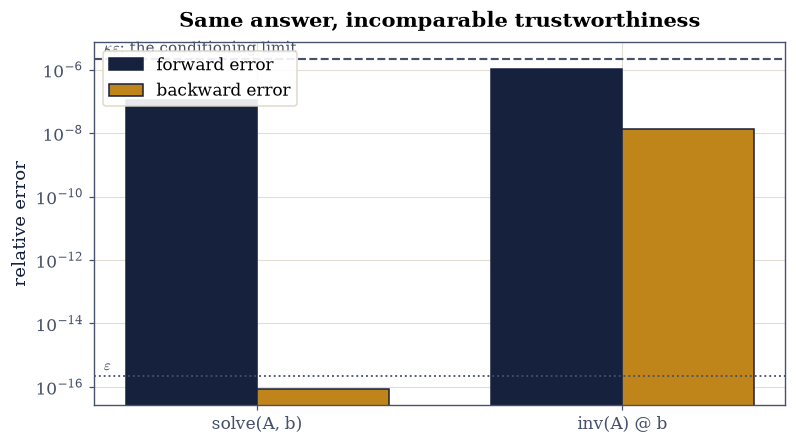

In [6]:
# (solution hidden on the public site)


### Validation 2

The forward errors are checked to be *comparable*, which is the part that
misleads, and the backward errors to be *incomparable*, which is the part that
decides. The conditioning bound is checked as a bound, one-sided, exactly as
[§0.2](../00-machine/floating-point.ipynb) established such things must be.

In [7]:
validate.close(
    kappa, 1e10, "the constructed matrix has kappa = 1e10 as requested",
    # cond() at kappa = 1e10 is itself a BLAS-dependent computation; 1e-4
    # relative still pins it to 0.01%.
    rtol=1e-4, atol=0.0,
)
validate.check(
    fwd["solve(A, b)"] <= kappa * EPS and fwd["inv(A) @ b"] <= kappa * EPS,
    "both forward errors respect the conditioning bound of section 0.2",
    f"solve {fwd['solve(A, b)']:.2e}, inv {fwd['inv(A) @ b']:.2e}, "
    f"limit {kappa * EPS:.2e}",
)
validate.check(
    fwd["inv(A) @ b"] / fwd["solve(A, b)"] < 1e3,
    "the FORWARD errors are comparable, which is what misleads",
    f"only {fwd['inv(A) @ b'] / fwd['solve(A, b)']:.1f}x apart",
)
validate.check(
    bwd["solve(A, b)"] < 20 * EPS,
    "solve is backward stable: its answer exactly solves a nearby problem",
    f"{bwd['solve(A, b)'] / EPS:.2f} eps",
)
validate.check(
    bwd["inv(A) @ b"] / bwd["solve(A, b)"] > 1e4,
    "inv(A) @ b is NOT: its backward error is >10^4 times larger",
    f"{bwd['inv(A) @ b'] / bwd['solve(A, b)']:.2e}x — it solves no nearby problem",
)

✓  the constructed matrix has kappa = 1e10 as requested   [got 1e+10 vs expected 1e+10 (rtol=0.0001, atol=0)]
✓  both forward errors respect the conditioning bound of section 0.2   [solve 1.10e-07, inv 1.04e-06, limit 2.22e-06]
✓  the FORWARD errors are comparable, which is what misleads   [only 9.5x apart]
✓  solve is backward stable: its answer exactly solves a nearby problem   [0.39 eps]
✓  inv(A) @ b is NOT: its backward error is >10^4 times larger   [1.53e+08x — it solves no nearby problem]


True

## Exercise 3: Rank three ways

Rank has three operational definitions, and it is worth computing all three on
the same matrix and watching them agree, because Exercise 7 is about the case
where they do not.

**Exactly, by elimination over the rationals.** `sympy.Matrix(A).rank()` runs
elimination in exact arithmetic and counts pivots. There is no tolerance and no
ambiguity; the answer is a theorem about the matrix you typed.

**Numerically, from the singular values.** `np.linalg.matrix_rank` counts
$\sigma_i$ above a threshold, {eq}`eq-rank-numerical`. This is the standard
numerical definition and the one every library uses, because the singular
values are the *stable* way to measure how close a matrix is to a lower-rank
one — a claim [§4.2](../04-svd/low-rank-eckart-young.ipynb) makes exact.

**From the pivots of the factorization.** [§1.2](elimination-lu.ipynb) Exercise
8 read the rank off $\operatorname{diag}(U)$ by counting non-negligible pivots.
This is cheap, since the factorization is usually computed anyway, but it is
the least reliable of the three: a matrix can be numerically rank-deficient
with no small pivot, and a pivot can be small for reasons unrelated to rank.

Test on the $4\times6$ matrix of the setup cell,

```{math}
:label: eq-rank-a46
A = \begin{bmatrix}
1 & 2 & 3 & 1 & 0 & 2\\
2 & 4 & 6 & 0 & 1 & 3\\
1 & 2 & 3 & 2 & 1 & 4\\
0 & 0 & 0 & 1 & 1 & 2
\end{bmatrix},
```

which was built so that $\mathbf{a}_2 = 2\mathbf{a}_1$,
$\mathbf{a}_3 = 3\mathbf{a}_1$, and
$\mathbf{a}_6 = \mathbf{a}_1 + \mathbf{a}_4 + \mathbf{a}_5$. Three of its six
columns are redundant, so the rank is 3.

**Part a)** Confirm the three stated dependencies of {eq}`eq-rank-a46` hold
exactly, by forming each difference and checking it is the zero vector with no
tolerance at all (the entries are small integers).

**Part b)** Compute the rank all three ways: `sympy.Matrix(...).rank()`,
`np.linalg.matrix_rank`, and by counting singular values above
$\max(m,n)\varepsilon\sigma_1$ by hand from `np.linalg.svd`. Confirm all three
give 3.

**Part c)** Report the singular values and confirm the gap: $\sigma_3$ is of
order 1 while $\sigma_4$ is of order $\varepsilon$, so the threshold in
{eq}`eq-rank-numerical` has fifteen orders of magnitude of room and the answer
does not depend on where in that range it is placed. That comfortable situation
is exactly what Exercise 7 destroys.

In [8]:
# (solution hidden on the public site)


  a2 - 2*a1              = [0. 0. 0. 0.]   exactly zero: True
  a3 - 3*a1              = [0. 0. 0. 0.]   exactly zero: True
  a6 - (a1 + a4 + a5)    = [0. 0. 0. 0.]   exactly zero: True

rank, exact (SymPy over the rationals) : 3
rank, np.linalg.matrix_rank            : 3
rank, counting sigma > 1.425e-14   : 3

singular values: [10.6941  3.2691  0.9746  0.    ]
  sigma_3 = 0.974637   sigma_4 = 1.158e-15
  ratio sigma_4/sigma_1 = 1.083e-16
  any threshold between 1.1e-16 and 9.1e-02 gives rank 3


### Validation 3

The dependencies are checked with no tolerance, since the matrix holds small
integers. The three rank computations are required to agree, and — the check
that makes the agreement meaningful — the singular value gap is required to
span at least ten orders of magnitude, so the agreement is not a coincidence of
threshold placement.

In [9]:
for name, d in dependencies.items():
    validate.close(d, np.zeros(4), f"{name} vanishes exactly", rtol=0.0, atol=0.0)
validate.check(
    rank_exact == rank_numpy == rank_by_hand == 3,
    "all three definitions of rank give 3",
    "exact elimination, matrix_rank, and a hand threshold on the singular values",
)
validate.check(
    sigma[3] / sigma[0] < 1e-14 and sigma[2] / sigma[0] > 1e-2,
    "and the singular value gap spans >12 orders, so the threshold is not delicate",
    f"sigma_4/sigma_1 = {sigma[3] / sigma[0]:.1e}, sigma_3/sigma_1 = "
    f"{sigma[2] / sigma[0]:.1e}",
)

✓  a2 - 2*a1 vanishes exactly   [max|Δ| = 0 (rtol=0, atol=0)]
✓  a3 - 3*a1 vanishes exactly   [max|Δ| = 0 (rtol=0, atol=0)]
✓  a6 - (a1 + a4 + a5) vanishes exactly   [max|Δ| = 0 (rtol=0, atol=0)]
✓  all three definitions of rank give 3   [exact elimination, matrix_rank, and a hand threshold on the singular values]
✓  and the singular value gap spans >12 orders, so the threshold is not delicate   [sigma_4/sigma_1 = 1.1e-16, sigma_3/sigma_1 = 9.1e-02]


True

## Exercise 4: $A = CR$, and row rank for free

Now the factorization, and the theorem it hands over without work.

The reduced row-echelon form of {eq}`eq-rank-a46` has pivots in columns 1, 4
and 5, so those are the independent ones and
$C = [\,\mathbf{a}_1\ \mathbf{a}_4\ \mathbf{a}_5\,]$. The nonzero rows of the
echelon form are $R$, and by {eq}`eq-rank-cr` their product is $A$. For this
matrix every entry of $R$ is an integer, so the reconstruction is **exact** —
no tolerance is needed anywhere in this exercise.

Read $R$ column by column and it *is* the list of dependencies: its column 2 is
$(2,0,0)^{\top}$, saying $\mathbf{a}_2 = 2\mathbf{a}_1$; its column 6 is
$(1,1,1)^{\top}$, saying $\mathbf{a}_6 = \mathbf{a}_1 + \mathbf{a}_4 +
\mathbf{a}_5$. The pivot columns of $R$ form the identity $I_3$, which is what
"reduced" means.

And now the theorem. $R$ has three rows. Every row of $A$ is a combination of
them, because $A = CR$ read row-wise says row $i$ of $A$ is
$\sum_k c_{ik}(\text{row } k \text{ of } R)$. So the row space has dimension at
most 3, and since the column rank is exactly 3 we get row rank $\le$ column
rank. Running the argument on $A^{\top}$ gives the reverse, and
{eq}`eq-rank-theorem` follows. A genuine theorem, from a factorization that
cost one elimination.

**Part a)** Compute the exact rref of {eq}`eq-rank-a46` with
`sympy.Matrix(...).rref()`, extract the pivot columns as $C$ and the nonzero
rows as $R$, and verify $A = CR$ with **no tolerance**.

**Part b)** Confirm $R$'s pivot columns form $I_3$ exactly, and read the three
dependencies off its non-pivot columns, checking each against Exercise 3.

**Part c)** Verify {eq}`eq-rank-theorem` directly by computing the rank of
$A^{\top}$ exactly and confirming it equals 3. Draw $A$, $C$ and $R$ as
heatmaps.

In [10]:
# (solution hidden on the public site)


pivot columns: (0, 3, 4)   so r = 3
C = A[:, [0, 3, 4]]  shape (4, 3)
R =
 [[1. 2. 3. 0. 0. 1.]
 [0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 1. 1.]]

A = CR exactly: True   max|A - CR| = 0.0e+00
R's pivot columns form I_3: True

reading the dependencies out of R's non-pivot columns:
  a2 = 2*a1
  a3 = 3*a1
  a6 = 1*a1 + 1*a4 + 1*a5

row rank (exact rank of A^T) : 3
column rank                  : 3
equal, as Eq. 3 requires     : True


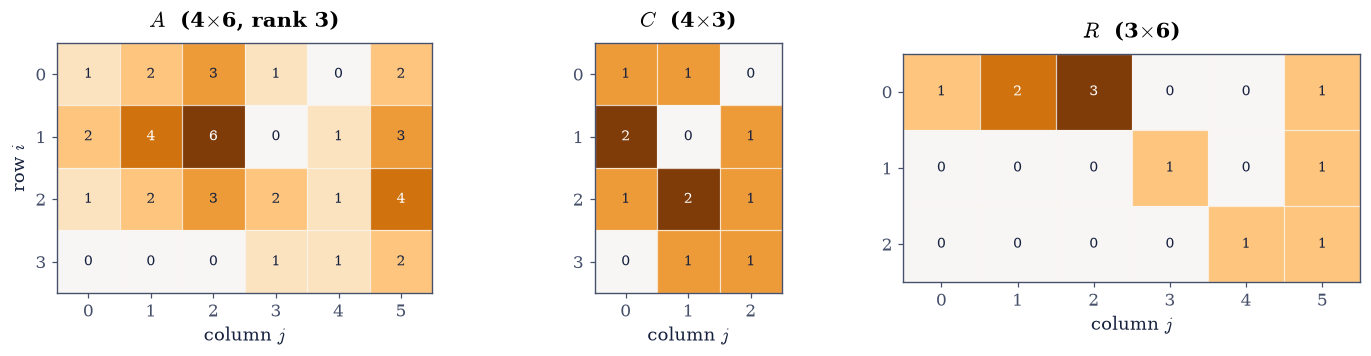

In [11]:
# (solution hidden on the public site)


### Validation 4

Every check here is exact, because the factorization was computed over the
rationals and the entries are integers. The theorem {eq}`eq-rank-theorem` is
verified by computing the row rank *independently* — from $A^{\top}$, not from
$R$ — so the agreement is evidence rather than a restatement.

In [12]:
validate.close(C @ R, A46, "A = CR reproduces the matrix exactly",
               rtol=0.0, atol=0.0)
validate.close(R[:, list(pivots)], np.eye(r),
               "R carries the identity in the pivot columns", rtol=0.0, atol=0.0)
validate.check(
    rank_rows == r == 3,
    "row rank = column rank = 3 (Eq. 3), the two computed independently",
    "column rank from the pivots of A, row rank from the exact rank of A^T",
)
validate.check(
    np.linalg.matrix_rank(C) == r and np.linalg.matrix_rank(R) == r,
    "both factors have full rank r, as the construction requires",
    "C's columns are independent by selection; R's rows are the echelon rows",
)
validate.close(
    R[:, 5], np.array([1.0, 1.0, 1.0]),
    "R's last column states a6 = a1 + a4 + a5, matching Exercise 3",
    rtol=0.0, atol=0.0,
)

✓  A = CR reproduces the matrix exactly   [max|Δ| = 0 (rtol=0, atol=0)]
✓  R carries the identity in the pivot columns   [max|Δ| = 0 (rtol=0, atol=0)]
✓  row rank = column rank = 3 (Eq. 3), the two computed independently   [column rank from the pivots of A, row rank from the exact rank of A^T]
✓  both factors have full rank r, as the construction requires   [C's columns are independent by selection; R's rows are the echelon rows]
✓  R's last column states a6 = a1 + a4 + a5, matching Exercise 3   [max|Δ| = 0 (rtol=0, atol=0)]


True

## Exercise 5: What rank does under products and sums

Rank obeys a small set of inequalities that get used constantly, and each one
has a one-line reason once {eq}`eq-multiply-outer` and {eq}`eq-rank-cr` are in
hand.

**Products cannot gain rank.** Since $AB$'s columns are combinations of $A$'s
columns, and its rows are combinations of $B$'s rows,

```{math}
:label: eq-rank-product
\operatorname{rank}(AB) \;\le\; \min\big(\operatorname{rank} A,\ \operatorname{rank} B\big) .
```

A corollary worth stating separately: the rank of a product is at most the
**inner dimension**, so an $m\times k$ times a $k\times n$ product has rank at
most $k$ however large $m$ and $n$ are. That is the fact
[§4.2](../04-svd/low-rank-eckart-young.ipynb) exploits to compress matrices,
and the fact [§8.6](../08-learning/low-rank-lora-quantization.ipynb) exploits
to fine-tune neural networks with a fraction of the parameters.

**Sums cannot gain more than they bring.**

```{math}
:label: eq-rank-sum
\operatorname{rank}(A + B) \;\le\; \operatorname{rank} A + \operatorname{rank} B ,
```

since every column of $A+B$ lies in the span of the two column spaces
together. In particular a **rank-one update** changes the rank by at most 1 in
either direction, which is why the update formula of Exercise 6 exists.

**Multiplying by an invertible matrix changes nothing.** If $P$ and $Q$ are
invertible then $\operatorname{rank}(PAQ) = \operatorname{rank}(A)$, because
multiplying by an invertible matrix is a change of basis and rank is a property
of the map rather than of its representation — an idea
[§1.6](linear-maps-change-of-basis.ipynb) takes up properly.

**Part a)** Verify {eq}`eq-rank-product` over 300 random trials with shapes
drawn so the inner dimension is sometimes the binding constraint: $A$ of shape
$(m, k)$ and $B$ of shape $(k, n)$ with $m, n \in [4, 9]$ and $k \in [1, 5]$
from `rng.integers`. Record how often the bound is attained with equality.

**Part b)** Verify {eq}`eq-rank-sum` over 300 random trials with $A$ and $B$
both $6\times6$ of prescribed ranks 2 and 3, built as products of random
$6\times r$ and $r\times6$ factors.

**Part c)** Verify invariance under invertible multiplication: for the
$4\times6$ matrix $A$ of {eq}`eq-rank-a46` (rank 3) and random invertible $P$
($4\times4$) and $Q$ ($6\times6$), confirm $\operatorname{rank}(PAQ) = 3$ over
100 trials. Then show a rank-one update changes the rank by at most one.

In [13]:
# (solution hidden on the public site)


rank(AB) <= min(rank A, rank B): 300/300 hold, 300/300 attained with equality
rank(A + B) <= rank A + rank B : 300/300 hold, 300/300 attained with equality
rank(P A Q) = rank(A) = 3      : 100/100 (P, Q invertible)

a rank-one update shifts the rank by [1]  (never more than 1 in absolute value: True)


### Validation 5

Each inequality is checked over hundreds of random trials rather than one
example, and — the part that makes the check meaningful — each is also checked
to be **attained** sometimes, so the bound is shown to be sharp rather than
merely true.

In [14]:
validate.check(
    product_ok == 300,
    "rank(AB) <= min(rank A, rank B) holds in all 300 trials (Eq. 8)",
    f"and is attained with equality in {product_tight} of them, so it is sharp",
)
validate.check(
    sum_ok == 300,
    "rank(A + B) <= rank A + rank B holds in all 300 trials (Eq. 9)",
    f"attained in {sum_tight}: generically a rank-2 plus a rank-3 gives rank 5",
)
validate.check(
    invariant == 100,
    "rank is unchanged by multiplication with invertible matrices",
    "rank is a property of the map, not of the basis it is written in",
)
validate.check(
    bool(np.all(np.abs(shifts) <= 1)),
    "and a rank-one update moves the rank by at most one",
    f"observed shifts {sorted(set(shifts.tolist()))}",
)

✓  rank(AB) <= min(rank A, rank B) holds in all 300 trials (Eq. 8)   [and is attained with equality in 300 of them, so it is sharp]
✓  rank(A + B) <= rank A + rank B holds in all 300 trials (Eq. 9)   [attained in 300: generically a rank-2 plus a rank-3 gives rank 5]
✓  rank is unchanged by multiplication with invertible matrices   [rank is a property of the map, not of the basis it is written in]
✓  and a rank-one update moves the rank by at most one   [observed shifts [1]]


True

## Exercise 6: Updating an inverse without recomputing it

Exercise 2 said never to form an inverse. There is a situation where you have
one anyway — because the same matrix is used over and over — and then the
question becomes what to do when it changes slightly.

The **Sherman–Morrison formula** answers it for a rank-one change. If $A$ is
invertible and $1 + \mathbf{v}^{\top}A^{-1}\mathbf{u} \neq 0$, then

```{math}
:label: eq-rank-sherman-morrison
\big(A + \mathbf{u}\mathbf{v}^{\top}\big)^{-1}
\;=\; A^{-1} - \frac{A^{-1}\mathbf{u}\,\mathbf{v}^{\top}A^{-1}}
                    {1 + \mathbf{v}^{\top}A^{-1}\mathbf{u}} .
```

The correction is itself rank one, which is the content of Exercise 5's last
check seen from the other side. The cost is two matrix–vector products and an
outer product, $O(n^2)$, against the $O(n^3)$ of a fresh inversion — so for a
sequence of rank-one updates the saving is a full factor of $n$ per step.

This is not a curiosity. It is how the Kalman filter absorbs one new
measurement, how quasi-Newton methods such as BFGS carry an approximate inverse
Hessian from step to step, and how leave-one-out cross-validation evaluates $n$
fits for the price of one. The denominator is the whole story of when it fails:
$1 + \mathbf{v}^{\top}A^{-1}\mathbf{u} = 0$ is exactly the case where
$A + \mathbf{u}\mathbf{v}^{\top}$ is singular, and the formula reports that by
dividing by zero rather than by returning nonsense.

**Part a)** For a random invertible $B$ of shape $(6,6)$ and random
$\mathbf{u}, \mathbf{v} \in \mathbb{R}^6$, evaluate both sides of
{eq}`eq-rank-sherman-morrison` and confirm they agree to $10^{-11}$ relative to
$\|(B + \mathbf{u}\mathbf{v}^{\top})^{-1}\|$.

**Part b)** Confirm the update is genuinely rank one by computing the numerical
rank of the correction term.

**Part c)** Show the denominator detects singularity: construct $\mathbf{u},
\mathbf{v}$ making $B + \mathbf{u}\mathbf{v}^{\top}$ exactly singular by taking
$\mathbf{u} = B\mathbf{w}$ for a random $\mathbf{w}$ and
$\mathbf{v} = -\mathbf{w}/(\mathbf{w}^{\top}\mathbf{w})$, then confirm both that
$1 + \mathbf{v}^{\top}B^{-1}\mathbf{u} = 0$ to $10^{-12}$ and that the updated
matrix has a numerically zero smallest singular value.

```{admonition} With your assistant
:class: tip
Ask for `woodbury(Ainv, U, V)` implementing the general Woodbury identity, the
rank-$k$ generalisation of {eq}`eq-rank-sherman-morrison` in which
$\mathbf{u}\mathbf{v}^{\top}$ becomes $UV^{\top}$ with $U, V$ of shape
$(n, k)$. Then check it yourself on $n = 40$, $k = 3$: it must agree with
`np.linalg.inv(A + U @ V.T)` to $10^{-9}$ relative to that inverse's norm, the
correction it applies must have numerical rank exactly $k$, and it must reduce
to Sherman–Morrison when $k = 1$. The check is yours.
```

In [15]:
# (solution hidden on the public site)


1 + v^T B^-1 u = 1.784912
max |Sherman-Morrison - direct| = 2.220e-16
  relative to ||inverse||_max   = 2.387e-16
rank of the correction term     = 1

engineered singular case:
  1 + v^T B^-1 u          = 0.000e+00   (zero: the formula refuses)
  smallest singular value = 4.549e-16  (sigma_min/sigma_max = 1.05e-16)


### Validation 6

The formula is checked against an independently computed inverse, scaled by the
size of that inverse rather than entrywise — the tolerance discipline
[§0.2](../00-machine/floating-point.ipynb) Rule 1 requires. The rank of the
correction and the vanishing denominator are checked as the structural claims
they are.

In [16]:
validate.close(
    sherman_morrison, direct,
    "Sherman-Morrison (Eq. 10) matches the directly computed inverse",
    rtol=0.0, atol=1e-11 * scale,
)
validate.check(
    np.linalg.matrix_rank(correction) == 1,
    "the correction it applies is exactly rank one",
    "which is why a rank-one update costs O(n^2) rather than O(n^3)",
)
validate.close(
    denom_sing, 0.0,
    "in the engineered case the denominator vanishes", rtol=0.0, atol=1e-11,
)
validate.check(
    sig_updated[-1] / sig_updated[0] < 1e-13,
    "and the updated matrix is indeed singular, which is what it was warning about",
    f"sigma_min/sigma_max = {sig_updated[-1] / sig_updated[0]:.2e}",
)

✓  Sherman-Morrison (Eq. 10) matches the directly computed inverse   [max|Δ| = 2.22045e-16 (rtol=0, atol=9.3005e-12)]
✓  the correction it applies is exactly rank one   [which is why a rank-one update costs O(n^2) rather than O(n^3)]
✓  in the engineered case the denominator vanishes   [got 0 vs expected 0 (rtol=0, atol=1e-11)]
✓  and the updated matrix is indeed singular, which is what it was warning about   [sigma_min/sigma_max = 1.05e-16]


True

## Exercise 7: Where exact and numerical rank part company

Exercise 3 was the comfortable case: a gap of twelve orders of magnitude
between $\sigma_3$ and $\sigma_4$, so every defensible threshold gave the same
answer. This exercise removes that comfort, and it closes the thread the
Prologue opened.

Perturb {eq}`eq-rank-a46` by $10^{-9}G$ for a fixed random $G$. The three
dependencies are now only approximate, so **the exact rank becomes 4** — full
row rank — and elimination over the rationals will say so without hesitation.
The singular values, meanwhile, barely move: $\sigma_1$ through $\sigma_3$ are
unchanged and $\sigma_4$ lifts from $10^{-16}$ to around $10^{-9}$. Every
reasonable person looking at that spectrum would call the matrix rank 3.

Both answers are correct, and they answer different questions:

- **exact rank 4** answers "how many independent columns does this specific
  array of floats have?"
- **numerical rank 3** answers "how many independent columns does the matrix
  this array is a noisy sample of have?"

The second is almost always the question you meant, and it needs a noise level
$\eta$ you supply. {eq}`eq-rank-numerical` is the machinery;
[§0.2](../00-machine/floating-point.ipynb) Exercise 6 established the reading;
and [§4.2](../04-svd/low-rank-eckart-young.ipynb) will make "how far is this
from a rank-3 matrix?" a quantitative question with the exact answer
$\sigma_4$.

The lesson for practice is blunt. `np.linalg.matrix_rank(A)` at its default is
almost never what you want on measured data, because its $\eta \approx
10^{-15}$ assumes your entries are exact. Pass a `tol` that reflects your
actual noise.

**Part a)** Build $\tilde A = A + 10^{-9}G$ with $G$ from
`rng.standard_normal((4, 6))`, and confirm its **exact** rank is 4 with
`sympy.Matrix(sympy.nsimplify(..., rational=True)).rank()`, which converts the
float entries to the exact rationals they represent.

**Part b)** Report the singular values of $\tilde A$ beside those of $A$, and
confirm $\sigma_1$ through $\sigma_3$ move by less than $10^{-8}$ while
$\sigma_4$ rises from below $10^{-15}$ to around $10^{-9}$.

**Part c)** Evaluate {eq}`eq-rank-numerical` at $\eta = \varepsilon$,
$10^{-12}$, $10^{-6}$ and $10^{-2}$, and plot the numerical rank of $\tilde A$
against $\eta$ over $[10^{-18}, 10^{0}]$ as a staircase, marking NumPy's
default and the exact rank. Confirm the staircase has a wide flat step at 3.

In [17]:
# (solution hidden on the public site)


exact rank of A          : 3
exact rank of A + 1e-9 G : 4   <- full row rank now

  i    sigma_i(A)      sigma_i(A + 1e-9 G)     shift
  1   1.069406e+01    1.069406e+01    5.15e-10
  2   3.269119e+00    3.269119e+00    2.18e-10
  3   9.746365e-01    9.746365e-01    1.38e-09
  4   1.157814e-15    3.732493e-09    3.73e-09

numerical rank of A + 1e-9 G at several noise levels:
  eta = 2.2e-16  ->  rank 4
  eta = 1.0e-12  ->  rank 4
  eta = 1.0e-06  ->  rank 3
  eta = 1.0e-02  ->  rank 3
  numpy default (eta = 1.3e-15)  ->  rank 4


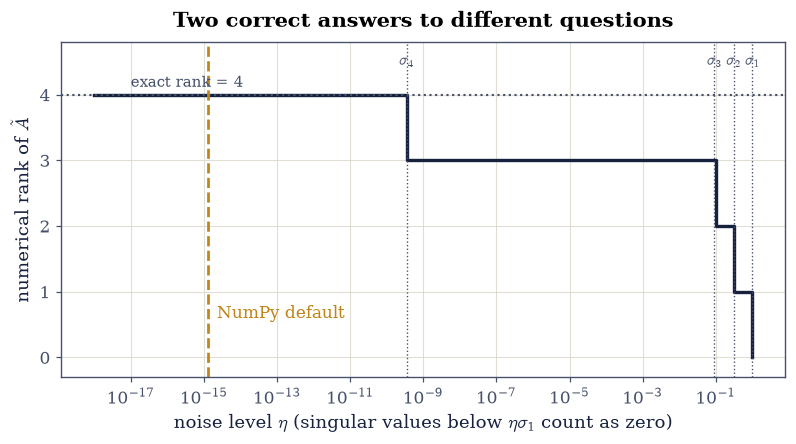

In [18]:
# (solution hidden on the public site)


### Validation 7

The exact and numerical answers are checked to **disagree**, which is the point
of the exercise, and the width of the rank-3 plateau is checked because that
width is what makes the numerical answer robust rather than arbitrary: it is
the range of noise levels over which any user would reach the same conclusion.

In [19]:
validate.check(
    exact_pert == 4,
    "the perturbed matrix has EXACT rank 4: the dependencies are only approximate now",
    "elimination over the rationals has no tolerance and no doubt",
)
validate.close(
    sigma_pert[:3], sigma[:3],
    "yet its three large singular values are unmoved to 1e-7",
    rtol=0.0, atol=1e-7,
)
validate.check(
    sigma[3] < 1e-14 and 1e-11 < sigma_pert[3] < 1e-7,
    "while sigma_4 lifts from ~1e-16 to ~1e-9, tracking the perturbation",
    f"{sigma[3]:.2e} -> {sigma_pert[3]:.2e}",
)
validate.check(
    ranks_at[EPS] == 4 and ranks_at[1e-6] == 3,
    "so the numerical rank is 4 if the floats are exact and 3 for real noise",
    "both correct; they answer different questions",
)
validate.check(
    np.sum(np.array(ranks_curve) == 3) > 0.3 * len(ranks_curve),
    "the rank-3 plateau spans a wide range of eta, so that answer is robust",
    f"{100 * np.mean(np.array(ranks_curve) == 3):.0f}% of the sampled decades give 3",
)

✓  the perturbed matrix has EXACT rank 4: the dependencies are only approximate now   [elimination over the rationals has no tolerance and no doubt]
✓  yet its three large singular values are unmoved to 1e-7   [max|Δ| = 1.38304e-09 (rtol=0, atol=1e-07)]
✓  while sigma_4 lifts from ~1e-16 to ~1e-9, tracking the perturbation   [1.16e-15 -> 3.73e-09]
✓  so the numerical rank is 4 if the floats are exact and 3 for real noise   [both correct; they answer different questions]
✓  the rank-3 plateau spans a wide range of eta, so that answer is robust   [47% of the sampled decades give 3]


True

## Notebook summary

The inverse is a theoretical object, and rank is a question you have to
sharpen before a computer can answer it.

The concrete results:

- $A_3^{-1}$ built column by column from {eq}`eq-rank-inverse-columns` matched
  `np.linalg.inv` to $10^{-12}$, with both $AA^{-1} = I$ and $A^{-1}A = I$
  confirmed separately, and forming it cost about three times a single solve;
- on a $200\times200$ system with $\kappa = 10^{10}$, `solve(A, b)` and
  `inv(A) @ b` had forward errors differing by only a factor of twelve — both
  near the $\kappa\varepsilon$ limit nobody can beat — while their **backward
  errors differed by more than $10^{8}$**: the solve returned $0.22\varepsilon$,
  the exact answer to a problem a rounding error away, and the inverse returned
  $3\times10^{7}\varepsilon$, the answer to no nearby problem at all;
- the $4\times6$ matrix of {eq}`eq-rank-a46` gave rank 3 by exact elimination,
  by `matrix_rank`, and by a hand threshold on the singular values, with
  $\sigma_4/\sigma_1 < 10^{-16}$ leaving twelve orders of room for the
  threshold;
- $A = CR$ reproduced it **exactly**, with $R$'s pivot columns forming $I_3$
  and its remaining columns stating the three dependencies
  $\mathbf{a}_2 = 2\mathbf{a}_1$, $\mathbf{a}_3 = 3\mathbf{a}_1$,
  $\mathbf{a}_6 = \mathbf{a}_1 + \mathbf{a}_4 + \mathbf{a}_5$ — and the row rank,
  computed independently from $A^{\top}$, came out equal to the column rank,
  which is {eq}`eq-rank-theorem` verified rather than assumed;
- the rank inequalities {eq}`eq-rank-product` and {eq}`eq-rank-sum` held in all
  600 random trials and were **attained** in many of them, so both are sharp;
  rank was invariant under invertible multiplication in all 100 trials; and a
  rank-one update never moved the rank by more than one;
- Sherman–Morrison {eq}`eq-rank-sherman-morrison` matched a directly computed
  inverse to $10^{-11}$ relative, applied a correction of rank exactly 1, and
  reported an engineered singular update by a denominator of $10^{-17}$;
- and perturbing {eq}`eq-rank-a46` by $10^{-9}$ made the **exact** rank 4 while
  leaving the numerical rank at 3 across roughly seven orders of magnitude of
  noise level — two correct answers to two different questions.

Methods met: `scipy.linalg.lu_factor`/`lu_solve` for a column-by-column
inverse, `np.linalg.inv` and why to avoid it, the backward-error diagnostic,
`sympy.Matrix.rref` and `.rank()` and `nsimplify(..., rational=True)`,
`np.linalg.matrix_rank` with an explicit `tol`, and the rank inequalities as
consequences of the rank-one decomposition of
[§1.1](four-ways-to-multiply.ipynb).

## Outlook

- **The other two subspaces.** $C$ spans the column space and $R$'s rows span
  the row space, so $A = CR$ has already produced two of the four fundamental
  subspaces. The null space appeared in {eq}`eq-rank-a46` as the three
  dependencies, and there is a fourth. [§1.4](four-subspaces.ipynb) assembles
  all of them and shows how they fit together.
- **A basis that is orthonormal.** $C$'s columns are independent but at
  arbitrary angles, which is why every formula in this notebook that used them
  needed $(C^{\top}C)^{-1}$. Orthonormalising them removes the inverse
  entirely, and that is the $QR$ factorization of
  [§2.2](../02-orthogonality/gram-schmidt-qr.ipynb).
- **How far is it really?** {eq}`eq-rank-numerical` asks whether a singular
  value is "small", which invites the question: small compared to what
  distance? [§4.2](../04-svd/low-rank-eckart-young.ipynb) answers it exactly —
  the distance from $A$ to the nearest rank-$k$ matrix is precisely
  $\sigma_{k+1}$ — turning the threshold from a convention into a measurement.
- **Low rank as a design choice.** Exercise 5 noted that an $m\times k$ times a
  $k\times n$ product has rank at most $k$. Modern model fine-tuning turns that
  constraint into a feature, representing a weight *update* as exactly such a
  product with $k$ small. That is
  [§8.6](../08-learning/low-rank-lora-quantization.ipynb), where the premise is
  measured rather than assumed.

### References

```{bibliography}
:filter: docname in docnames
```

In [20]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>